In [1]:
import pandas as pd
import numpy as np
import sqlite3
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configura o caminho para o banco de dados
project_root = pathlib.Path("..") 
db_path = project_root / "banco de dados" / "crash_bot_historico.db"

print(f"Carregando dados de: {db_path}")

with sqlite3.connect(db_path) as conn:
    query = "SELECT timestamp, multiplicador FROM multiplicadores_historico ORDER BY timestamp ASC"
    df = pd.read_sql_query(query, conn, parse_dates=["timestamp"])

df = df.reset_index(drop=True)
multiplicadores = df['multiplicador'].values
print(f"✅ {len(multiplicadores):,} rodadas carregadas.")

Carregando dados de: ..\banco de dados\crash_bot_historico.db
✅ 105,281 rodadas carregadas.


In [2]:
# --- CÉLULA 2: DEFINIÇÃO DAS ESTRATÉGIAS ---

print("="*80)
print("🎰 COMPARAÇÃO DE ESTRATÉGIAS POR NÚMERO DE DOBRAS")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    ESTRATÉGIAS A COMPARAR                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 1-2 (2 dobras) - ULTRA CONSERVADORA                                      ║
║     • Gatilho: 6 baixas                                                      ║
║     • Dobras: 2 (proporção 1-2 = 3 partes)                                   ║
║     • Quebra se: 8+ baixas consecutivas                                      ║
║     • Aposta: Banca/3 na dobra 1, 2×Banca/3 na dobra 2                       ║
║                                                                              ║
║  📊 1-2-4 (3 dobras) - CONSERVADORA                                          ║
║     • Gatilho: 6 baixas                                                      ║
║     • Dobras: 3 (proporção 1-2-4 = 7 partes)                                 ║
║     • Quebra se: 9+ baixas consecutivas                                      ║
║                                                                              ║
║  📊 1-2-4-8 (4 dobras) - MODERADA                                            ║
║     • Gatilho: 6 baixas                                                      ║
║     • Dobras: 4 (proporção 1-2-4-8 = 15 partes)                              ║
║     • Quebra se: 10+ baixas consecutivas                                     ║
║                                                                              ║
║  📊 1-2-4-1-2-4 (6 dobras) - ATUAL                                           ║
║     • Gatilho: 6 baixas                                                      ║
║     • Dobras: 6 (dois ciclos de 1-2-4 = 14 partes)                           ║
║     • Quebra se: 12+ baixas consecutivas                                     ║
║                                                                              ║
║  📊 1-2-4-8-16 (5 dobras) - AGRESSIVA                                        ║
║     • Gatilho: 6 baixas                                                      ║
║     • Dobras: 5 (proporção 1-2-4-8-16 = 31 partes)                           ║
║     • Quebra se: 11+ baixas consecutivas                                     ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

Todas usam: Target 1.99x, Taxa da casa 1%
""")

🎰 COMPARAÇÃO DE ESTRATÉGIAS POR NÚMERO DE DOBRAS

╔══════════════════════════════════════════════════════════════════════════════╗
║                    ESTRATÉGIAS A COMPARAR                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📊 1-2 (2 dobras) - ULTRA CONSERVADORA                                      ║
║     • Gatilho: 6 baixas                                                      ║
║     • Dobras: 2 (proporção 1-2 = 3 partes)                                   ║
║     • Quebra se: 8+ baixas consecutivas                                      ║
║     • Aposta: Banca/3 na dobra 1, 2×Banca/3 na dobra 2                       ║
║                                                                              ║
║  📊 1-2-4 (3 dobras) - CONSERVADORA                                          ║
║     • Gatilho: 6 baixas                                    

In [3]:
# --- CÉLULA 3: FUNÇÃO DE SIMULAÇÃO GENÉRICA ---

def simular_estrategia(mult, banca=500, gatilho=6, dobras_config=None, target=1.99):
    """
    Simula uma estratégia de Martingale com configuração flexível de dobras.
    
    dobras_config: lista de proporções, ex: [1,2] para 1-2, [1,2,4] para 1-2-4
    """
    if dobras_config is None:
        dobras_config = [1, 2, 4, 1, 2, 4]  # Padrão: 1-2-4-1-2-4
    
    num_dobras = len(dobras_config)
    total_partes = sum(dobras_config)
    parte = banca / total_partes
    
    # Criar dicionário de apostas
    dobras = {i+1: parte * p for i, p in enumerate(dobras_config)}
    
    # Variáveis de resultado
    lucro_total = 0
    quebras = 0
    wins = {i+1: 0 for i in range(num_dobras)}
    entradas = 0
    historico = [0]
    detalhes_quebras = []
    
    i = 0
    while i < len(mult):
        # Contar baixas consecutivas
        lows = 0
        j = i
        while j < len(mult) and mult[j] < 2.0:
            lows += 1
            j += 1
        
        # Se atingiu o gatilho, entra!
        if lows >= gatilho:
            entradas += 1
            entrada_pos = i + gatilho
            perdas = 0
            ganhou = False
            
            # Tentar cada dobra
            for d in range(1, num_dobras + 1):
                pos = entrada_pos + (d - 1)
                if pos >= len(mult):
                    break
                
                aposta = dobras[d]
                
                if mult[pos] >= target:
                    # GANHOU!
                    ganho = aposta * (target - 1) * 0.99  # 1% taxa
                    lucro_total += ganho - perdas
                    wins[d] += 1
                    ganhou = True
                    break
                else:
                    # Perdeu esta dobra
                    perdas += aposta
            
            if not ganhou:
                # QUEBROU!
                lucro_total -= banca
                quebras += 1
                detalhes_quebras.append({
                    'posicao': i,
                    'sequencia': lows,
                    'lucro_momento': lucro_total
                })
            
            historico.append(lucro_total)
        
        i = j if j > i else i + 1
    
    # Calcular métricas
    total_wins = sum(wins.values())
    taxa_win = total_wins / entradas * 100 if entradas > 0 else 0
    lucro_por_entrada = lucro_total / entradas if entradas > 0 else 0
    
    # Drawdown
    serie = pd.Series(historico)
    pico = serie.cummax()
    drawdown = serie - pico
    max_drawdown = drawdown.min()
    
    return {
        'lucro': lucro_total,
        'quebras': quebras,
        'wins': wins,
        'entradas': entradas,
        'taxa_win': taxa_win,
        'lucro_por_entrada': lucro_por_entrada,
        'max_drawdown': max_drawdown,
        'historico': historico,
        'detalhes_quebras': detalhes_quebras,
        'dobras_config': dobras_config,
        'dobras_valores': dobras,
        'num_dobras': num_dobras,
        'quebra_se': gatilho + num_dobras
    }

print("✅ Função de simulação carregada!")

✅ Função de simulação carregada!


In [4]:
# --- CÉLULA 4: DEFINIR E EXECUTAR TODAS AS ESTRATÉGIAS ---

print("="*80)
print("⏳ EXECUTANDO SIMULAÇÕES...")
print("="*80)

BANCA = 500
TARGET = 1.99
GATILHO = 6

estrategias = {
    '1-2 (2 dobras)': {
        'dobras': [1, 2],
        'cor': '#9b59b6',
        'emoji': '🟣'
    },
    '1-2-4 (3 dobras)': {
        'dobras': [1, 2, 4],
        'cor': '#3498db',
        'emoji': '🔵'
    },
    '1-2-4-8 (4 dobras)': {
        'dobras': [1, 2, 4, 8],
        'cor': '#2ecc71',
        'emoji': '🟢'
    },
    '1-2-4-8-16 (5 dobras)': {
        'dobras': [1, 2, 4, 8, 16],
        'cor': '#f39c12',
        'emoji': '🟡'
    },
    '1-2-4-1-2-4 (6 dobras)': {
        'dobras': [1, 2, 4, 1, 2, 4],
        'cor': '#e74c3c',
        'emoji': '🔴'
    },
}

resultados = {}

for nome, config in estrategias.items():
    print(f"\n{config['emoji']} Simulando {nome}...")
    print(f"   Proporção: {config['dobras']}")
    print(f"   Total partes: {sum(config['dobras'])}")
    print(f"   Quebra se: {GATILHO + len(config['dobras'])}+ baixas")
    
    res = simular_estrategia(
        multiplicadores,
        banca=BANCA,
        gatilho=GATILHO,
        dobras_config=config['dobras'],
        target=TARGET
    )
    res['config'] = config
    res['nome'] = nome
    resultados[nome] = res
    
    print(f"   ✅ Entradas: {res['entradas']:,} | Quebras: {res['quebras']} | Lucro: R$ {res['lucro']:,.2f}")

print("\n" + "="*80)
print("✅ Todas as simulações concluídas!")

⏳ EXECUTANDO SIMULAÇÕES...

🟣 Simulando 1-2 (2 dobras)...
   Proporção: [1, 2]
   Total partes: 3
   Quebra se: 8+ baixas
   ✅ Entradas: 1,271 | Quebras: 272 | Lucro: R$ 26,135.27

🔵 Simulando 1-2-4 (3 dobras)...
   Proporção: [1, 2, 4]
   Total partes: 7
   Quebra se: 9+ baixas
   ✅ Entradas: 1,271 | Quebras: 118 | Lucro: R$ 20,610.94

🟢 Simulando 1-2-4-8 (4 dobras)...
   Proporção: [1, 2, 4, 8]
   Total partes: 15
   Quebra se: 10+ baixas
   ✅ Entradas: 1,271 | Quebras: 50 | Lucro: R$ 14,057.59

🟡 Simulando 1-2-4-8-16 (5 dobras)...
   Proporção: [1, 2, 4, 8, 16]
   Total partes: 31
   Quebra se: 11+ baixas
   ✅ Entradas: 1,271 | Quebras: 19 | Lucro: R$ 9,739.63

🔴 Simulando 1-2-4-1-2-4 (6 dobras)...
   Proporção: [1, 2, 4, 1, 2, 4]
   Total partes: 14
   Quebra se: 12+ baixas
   ✅ Entradas: 1,271 | Quebras: 6 | Lucro: R$ 12,676.12

✅ Todas as simulações concluídas!


In [5]:
# --- CÉLULA 5: TABELA COMPARATIVA DETALHADA ---

print("\n" + "="*100)
print("📊 COMPARAÇÃO DETALHADA DAS ESTRATÉGIAS POR NÚMERO DE DOBRAS")
print("="*100)

print(f"\nDados: {len(multiplicadores):,} rodadas | Banca: R$ {BANCA} | Target: {TARGET}x | Gatilho: {GATILHO}")

print("\n" + "-"*100)
print(f"{'ESTRATÉGIA':<25} {'DOBRAS':>8} {'QUEBRA SE':>10} {'ENTRADAS':>10} {'QUEBRAS':>8} {'WIN %':>8} {'LUCRO':>15} {'LUCRO/ENT':>12}")
print("-"*100)

for nome, res in resultados.items():
    print(f"{nome:<25} {res['num_dobras']:>8} {res['quebra_se']:>9}+ {res['entradas']:>10,} {res['quebras']:>8} {res['taxa_win']:>7.2f}% R$ {res['lucro']:>12,.2f} R$ {res['lucro_por_entrada']:>9,.2f}")

print("="*100)


📊 COMPARAÇÃO DETALHADA DAS ESTRATÉGIAS POR NÚMERO DE DOBRAS

Dados: 105,281 rodadas | Banca: R$ 500 | Target: 1.99x | Gatilho: 6

----------------------------------------------------------------------------------------------------
ESTRATÉGIA                  DOBRAS  QUEBRA SE   ENTRADAS  QUEBRAS    WIN %           LUCRO    LUCRO/ENT
----------------------------------------------------------------------------------------------------
1-2 (2 dobras)                   2         8+      1,271      272   78.60% R$    26,135.27 R$     20.56
1-2-4 (3 dobras)                 3         9+      1,271      118   90.72% R$    20,610.94 R$     16.22
1-2-4-8 (4 dobras)               4        10+      1,271       50   96.07% R$    14,057.59 R$     11.06
1-2-4-8-16 (5 dobras)            5        11+      1,271       19   98.51% R$     9,739.63 R$      7.66
1-2-4-1-2-4 (6 dobras)           6        12+      1,271        6   99.53% R$    12,676.12 R$      9.97


In [6]:
# --- CÉLULA 6: ANÁLISE DE DISTRIBUIÇÃO DE SEQUÊNCIAS ---

print("\n" + "="*80)
print("📊 ANÁLISE: QUANTAS SEQUÊNCIAS DE CADA TAMANHO EXISTEM")
print("="*80)

# Contar sequências de baixas
sequencias = []
i = 0
while i < len(multiplicadores):
    lows = 0
    j = i
    while j < len(multiplicadores) and multiplicadores[j] < 2.0:
        lows += 1
        j += 1
    if lows >= GATILHO:
        sequencias.append(lows)
    i = j if j > i else i + 1

from collections import Counter
contagem = Counter(sequencias)

print(f"\nTotal de entradas (gatilho {GATILHO}+): {len(sequencias):,}")
print(f"\n{'TAMANHO':<15} {'QUANTIDADE':>12} {'%':>10} {'RESULTADO POR ESTRATÉGIA'}")
print("-"*80)

for tamanho in sorted(contagem.keys()):
    qtd = contagem[tamanho]
    pct = qtd / len(sequencias) * 100
    
    # Determinar resultado por estratégia
    resultado_1_2 = "✅ Win" if tamanho <= 7 else "❌ Quebra"
    resultado_1_2_4 = "✅ Win" if tamanho <= 8 else "❌ Quebra"
    resultado_1_2_4_8 = "✅ Win" if tamanho <= 9 else "❌ Quebra"
    resultado_1_2_4_8_16 = "✅ Win" if tamanho <= 10 else "❌ Quebra"
    resultado_1_2_4_1_2_4 = "✅ Win" if tamanho <= 11 else "❌ Quebra"
    
    print(f"{tamanho} baixas{'':<8} {qtd:>12,} {pct:>9.2f}%   1-2:{resultado_1_2} | 1-2-4:{resultado_1_2_4} | 1-2-4-8:{resultado_1_2_4_8} | 1-2-4-1-2-4:{resultado_1_2_4_1_2_4}")

print("\n" + "-"*80)
print("\n📊 RESUMO DE QUEBRAS POR ESTRATÉGIA:")
print("-"*60)

for nome, res in resultados.items():
    quebras_tamanhos = [t for t in sequencias if t >= res['quebra_se']]
    print(f"   {nome}: {len(quebras_tamanhos)} quebras (sequências >= {res['quebra_se']})")


📊 ANÁLISE: QUANTAS SEQUÊNCIAS DE CADA TAMANHO EXISTEM

Total de entradas (gatilho 6+): 1,271

TAMANHO           QUANTIDADE          % RESULTADO POR ESTRATÉGIA
--------------------------------------------------------------------------------
6 baixas                  679     53.42%   1-2:✅ Win | 1-2-4:✅ Win | 1-2-4-8:✅ Win | 1-2-4-1-2-4:✅ Win
7 baixas                  318     25.02%   1-2:✅ Win | 1-2-4:✅ Win | 1-2-4-8:✅ Win | 1-2-4-1-2-4:✅ Win
8 baixas                  153     12.04%   1-2:❌ Quebra | 1-2-4:✅ Win | 1-2-4-8:✅ Win | 1-2-4-1-2-4:✅ Win
9 baixas                   71      5.59%   1-2:❌ Quebra | 1-2-4:❌ Quebra | 1-2-4-8:✅ Win | 1-2-4-1-2-4:✅ Win
10 baixas                   31      2.44%   1-2:❌ Quebra | 1-2-4:❌ Quebra | 1-2-4-8:❌ Quebra | 1-2-4-1-2-4:✅ Win
11 baixas                   13      1.02%   1-2:❌ Quebra | 1-2-4:❌ Quebra | 1-2-4-8:❌ Quebra | 1-2-4-1-2-4:✅ Win
12 baixas                    6      0.47%   1-2:❌ Quebra | 1-2-4:❌ Quebra | 1-2-4-8:❌ Quebra | 1-2-4-1-2-4:❌ Que

In [7]:
# --- CÉLULA 7: DISTRIBUIÇÃO DE VITÓRIAS POR DOBRA ---

print("\n" + "="*80)
print("📈 DISTRIBUIÇÃO DE VITÓRIAS POR DOBRA")
print("="*80)

for nome, res in resultados.items():
    config = res['config']
    print(f"\n{config['emoji']} {nome}")
    print("-"*60)
    
    total_wins = sum(res['wins'].values())
    
    for dobra, qtd in res['wins'].items():
        baixa_num = GATILHO + dobra - 1
        pct_total = qtd / res['entradas'] * 100 if res['entradas'] > 0 else 0
        pct_wins = qtd / total_wins * 100 if total_wins > 0 else 0
        
        aposta = res['dobras_valores'][dobra]
        lucro_dobra = aposta * (TARGET - 1) * 0.99
        
        barra = '█' * int(pct_wins / 5)
        
        print(f"   Dobra {dobra} ({baixa_num}ª baixa): {qtd:>5} vitórias ({pct_total:>5.1f}%) | Aposta: R$ {aposta:>6.2f} | Lucro/win: R$ {lucro_dobra:>5.2f} {barra}")
    
    print(f"   {'─'*55}")
    print(f"   QUEBRAS ({res['quebra_se']}+ baixas): {res['quebras']:>5} ({res['quebras']/res['entradas']*100:.2f}%)")
    print(f"   TAXA DE VITÓRIA: {res['taxa_win']:.2f}%")


📈 DISTRIBUIÇÃO DE VITÓRIAS POR DOBRA

🟣 1-2 (2 dobras)
------------------------------------------------------------
   Dobra 1 (6ª baixa):   682 vitórias ( 53.7%) | Aposta: R$ 166.67 | Lucro/win: R$ 163.35 █████████████
   Dobra 2 (7ª baixa):   317 vitórias ( 24.9%) | Aposta: R$ 333.33 | Lucro/win: R$ 326.70 ██████
   ───────────────────────────────────────────────────────
   QUEBRAS (8+ baixas):   272 (21.40%)
   TAXA DE VITÓRIA: 78.60%

🔵 1-2-4 (3 dobras)
------------------------------------------------------------
   Dobra 1 (6ª baixa):   682 vitórias ( 53.7%) | Aposta: R$  71.43 | Lucro/win: R$ 70.01 ███████████
   Dobra 2 (7ª baixa):   317 vitórias ( 24.9%) | Aposta: R$ 142.86 | Lucro/win: R$ 140.01 █████
   Dobra 3 (8ª baixa):   154 vitórias ( 12.1%) | Aposta: R$ 285.71 | Lucro/win: R$ 280.03 ██
   ───────────────────────────────────────────────────────
   QUEBRAS (9+ baixas):   118 (9.28%)
   TAXA DE VITÓRIA: 90.72%

🟢 1-2-4-8 (4 dobras)
----------------------------------------

In [8]:
# --- CÉLULA 8: ANÁLISE DE RISCO/RETORNO ---

print("\n" + "="*80)
print("📊 ANÁLISE DE RISCO/RETORNO")
print("="*80)

# Calcular métricas adicionais
for nome, res in resultados.items():
    serie = pd.Series(res['historico'])
    retornos = serie.diff().dropna()
    
    res['volatilidade'] = retornos.std()
    res['sharpe'] = retornos.mean() / retornos.std() if retornos.std() > 0 else 0
    
    # Lucro por quebra (quanto precisa lucrar para cobrir 1 quebra)
    res['entradas_para_cobrir_quebra'] = BANCA / res['lucro_por_entrada'] if res['lucro_por_entrada'] > 0 else float('inf')
    
    # Frequência de quebra
    res['freq_quebra'] = res['entradas'] / res['quebras'] if res['quebras'] > 0 else float('inf')

print(f"\n{'ESTRATÉGIA':<25} {'LUCRO':>12} {'DRAWDOWN':>12} {'SHARPE':>10} {'VOL':>10} {'FREQ QUEBRA':>12}")
print("-"*90)

for nome, res in resultados.items():
    freq_str = f"1/{res['freq_quebra']:.0f}" if res['freq_quebra'] != float('inf') else "∞"
    print(f"{nome:<25} R$ {res['lucro']:>9,.2f} R$ {res['max_drawdown']:>9,.2f} {res['sharpe']:>10.4f} {res['volatilidade']:>10.2f} {freq_str:>12}")

print("\n" + "-"*90)
print("\n📊 INTERPRETAÇÃO:")
print("   • Sharpe Ratio: quanto maior, melhor relação risco/retorno")
print("   • Freq Quebra: 1/X significa que quebra a cada X entradas")
print("   • Volatilidade: variação do lucro entre entradas")


📊 ANÁLISE DE RISCO/RETORNO

ESTRATÉGIA                       LUCRO     DRAWDOWN     SHARPE        VOL  FREQ QUEBRA
------------------------------------------------------------------------------------------
1-2 (2 dobras)            R$ 26,135.27 R$ -5,116.08     0.0757     271.74          1/5
1-2-4 (3 dobras)          R$ 20,610.94 R$ -2,546.55     0.0982     165.21         1/11
1-2-4-8 (4 dobras)        R$ 14,057.59 R$ -2,151.91     0.1069     103.47         1/25
1-2-4-8-16 (5 dobras)     R$  9,739.63 R$ -1,165.14     0.1225      62.57         1/67
1-2-4-1-2-4 (6 dobras)    R$ 12,676.12 R$ -1,208.42     0.1261      79.10        1/212

------------------------------------------------------------------------------------------

📊 INTERPRETAÇÃO:
   • Sharpe Ratio: quanto maior, melhor relação risco/retorno
   • Freq Quebra: 1/X significa que quebra a cada X entradas
   • Volatilidade: variação do lucro entre entradas


In [9]:
# --- CÉLULA 9: ANÁLISE DE RECUPERAÇÃO ---

print("\n" + "="*80)
print("💰 ANÁLISE: QUANTAS ENTRADAS PARA RECUPERAR UMA QUEBRA?")
print("="*80)

print(f"\nBanca por entrada: R$ {BANCA}")
print(f"Perda por quebra: R$ {BANCA}")

print(f"\n{'ESTRATÉGIA':<25} {'LUCRO/ENTRADA':>15} {'ENTRADAS P/ RECUPERAR':>25} {'QUEBRAS':>10} {'BALANÇO':>15}")
print("-"*100)

for nome, res in resultados.items():
    entradas_recuperar = BANCA / res['lucro_por_entrada'] if res['lucro_por_entrada'] > 0 else float('inf')
    
    # Balanço: lucro total - prejuízo das quebras
    prejuizo_quebras = res['quebras'] * BANCA
    lucro_bruto = res['lucro'] + prejuizo_quebras  # Lucro antes das quebras
    
    if entradas_recuperar == float('inf'):
        ent_str = "∞ (prejuízo)"
    else:
        ent_str = f"{entradas_recuperar:.0f} entradas"
    
    # Verificar se é sustentável
    freq = res['freq_quebra']
    if freq != float('inf') and entradas_recuperar != float('inf'):
        sustentavel = "✅" if freq > entradas_recuperar else "❌"
    else:
        sustentavel = "✅" if res['lucro'] > 0 else "❌"
    
    print(f"{nome:<25} R$ {res['lucro_por_entrada']:>12,.2f} {ent_str:>25} {res['quebras']:>10} R$ {res['lucro']:>12,.2f} {sustentavel}")

print("\n" + "-"*100)
print("\n✅ = Sustentável (frequência de quebra > entradas para recuperar)")
print("❌ = Não sustentável (quebra mais rápido do que recupera)")


💰 ANÁLISE: QUANTAS ENTRADAS PARA RECUPERAR UMA QUEBRA?

Banca por entrada: R$ 500
Perda por quebra: R$ 500

ESTRATÉGIA                  LUCRO/ENTRADA     ENTRADAS P/ RECUPERAR    QUEBRAS         BALANÇO
----------------------------------------------------------------------------------------------------
1-2 (2 dobras)            R$        20.56               24 entradas        272 R$    26,135.27 ❌
1-2-4 (3 dobras)          R$        16.22               31 entradas        118 R$    20,610.94 ❌
1-2-4-8 (4 dobras)        R$        11.06               45 entradas         50 R$    14,057.59 ❌
1-2-4-8-16 (5 dobras)     R$         7.66               65 entradas         19 R$     9,739.63 ✅
1-2-4-1-2-4 (6 dobras)    R$         9.97               50 entradas          6 R$    12,676.12 ✅

----------------------------------------------------------------------------------------------------

✅ = Sustentável (frequência de quebra > entradas para recuperar)
❌ = Não sustentável (quebra mais rápido do

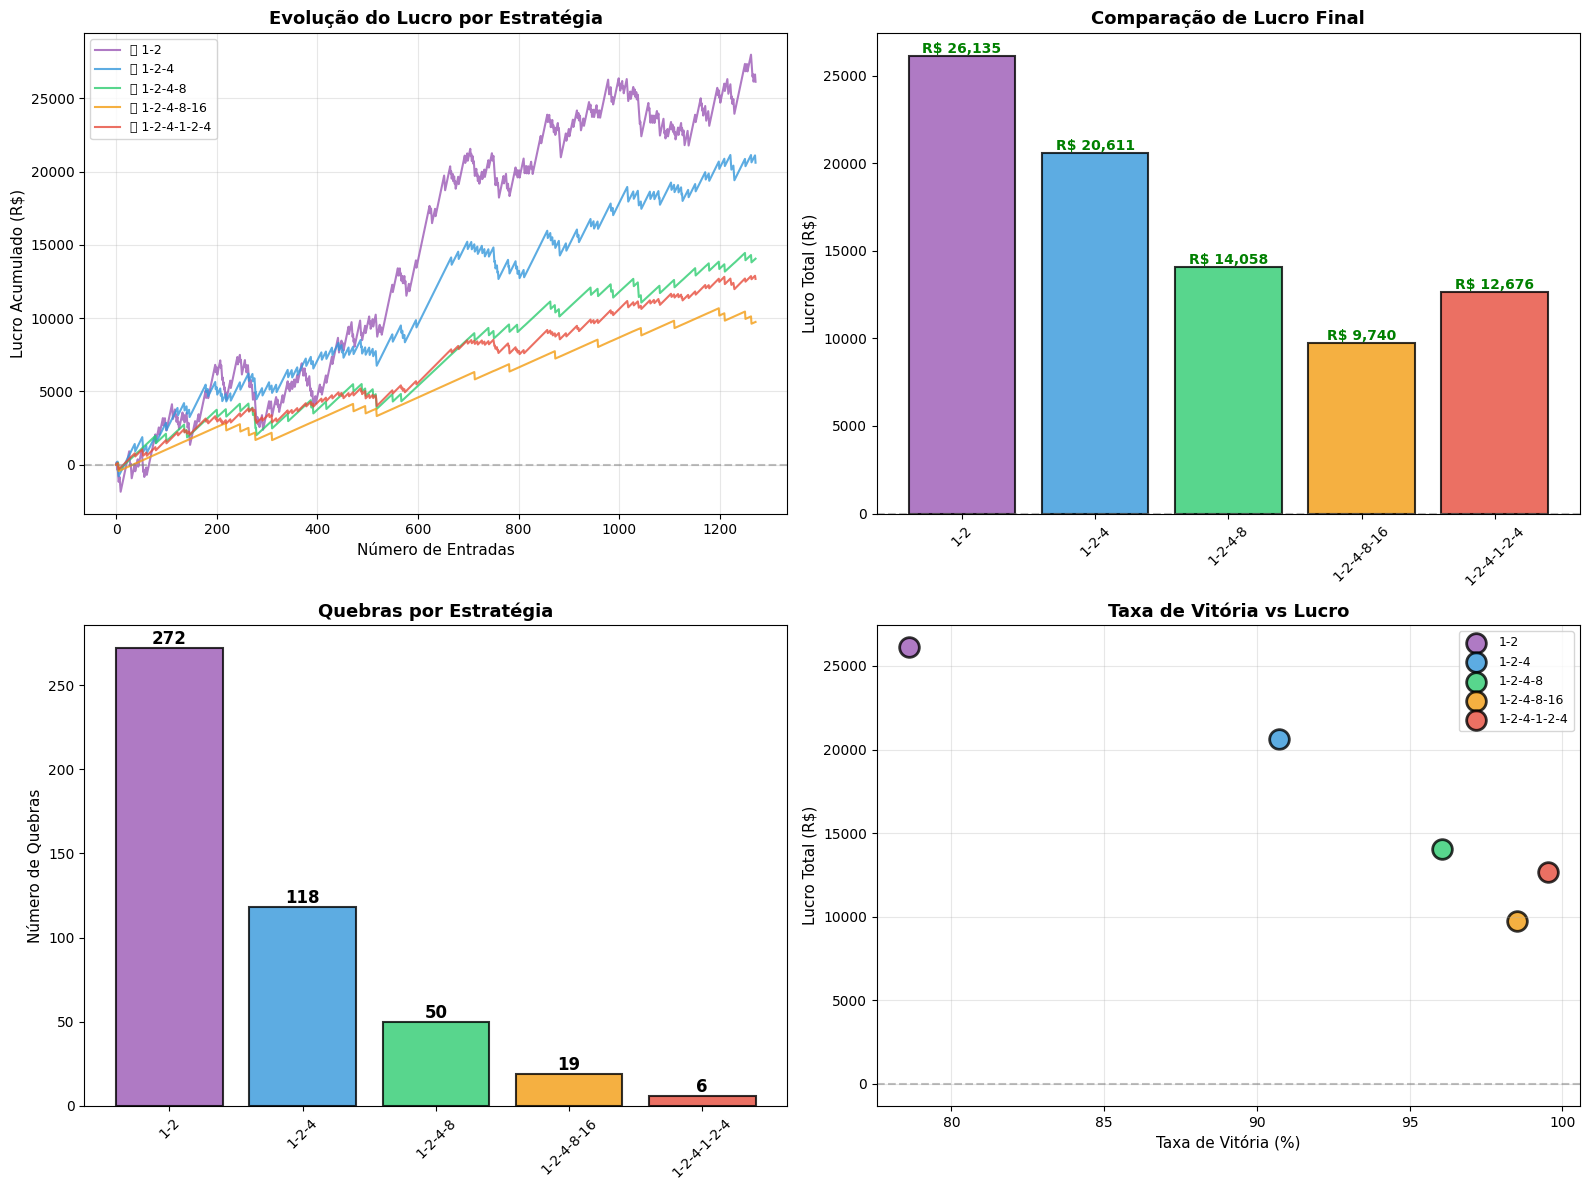


📁 Gráfico salvo: 01_comparacao_dobras.png


In [10]:
# --- CÉLULA 10: GRÁFICOS COMPARATIVOS ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Evolução do lucro
ax1 = axes[0, 0]
for nome, res in resultados.items():
    ax1.plot(res['historico'], label=f"{res['config']['emoji']} {nome.split('(')[0].strip()}", 
             color=res['config']['cor'], linewidth=1.5, alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Número de Entradas', fontsize=11)
ax1.set_ylabel('Lucro Acumulado (R$)', fontsize=11)
ax1.set_title('Evolução do Lucro por Estratégia', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Comparação de Lucro Final
ax2 = axes[0, 1]
nomes_curtos = [n.split('(')[0].strip() for n in resultados.keys()]
lucros = [r['lucro'] for r in resultados.values()]
cores = [r['config']['cor'] for r in resultados.values()]
bars = ax2.bar(nomes_curtos, lucros, color=cores, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Lucro Total (R$)', fontsize=11)
ax2.set_title('Comparação de Lucro Final', fontsize=13, fontweight='bold')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for bar, lucro in zip(bars, lucros):
    va = 'bottom' if lucro >= 0 else 'top'
    color = 'green' if lucro >= 0 else 'red'
    ax2.annotate(f'R$ {lucro:,.0f}', xy=(bar.get_x() + bar.get_width()/2, lucro),
                 ha='center', va=va, fontsize=10, fontweight='bold', color=color)
ax2.tick_params(axis='x', rotation=45)

# 3. Quebras por estratégia
ax3 = axes[1, 0]
quebras = [r['quebras'] for r in resultados.values()]
bars = ax3.bar(nomes_curtos, quebras, color=cores, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Número de Quebras', fontsize=11)
ax3.set_title('Quebras por Estratégia', fontsize=13, fontweight='bold')
for bar, q in zip(bars, quebras):
    ax3.annotate(f'{q}', xy=(bar.get_x() + bar.get_width()/2, q),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 4. Taxa de Vitória vs Lucro
ax4 = axes[1, 1]
taxas = [r['taxa_win'] for r in resultados.values()]
for nome, res in resultados.items():
    ax4.scatter(res['taxa_win'], res['lucro'], s=200, c=res['config']['cor'], 
                alpha=0.8, edgecolors='black', linewidth=2, label=nome.split('(')[0].strip())
ax4.set_xlabel('Taxa de Vitória (%)', fontsize=11)
ax4.set_ylabel('Lucro Total (R$)', fontsize=11)
ax4.set_title('Taxa de Vitória vs Lucro', fontsize=13, fontweight='bold')
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('01_comparacao_dobras.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Gráfico salvo: 01_comparacao_dobras.png")

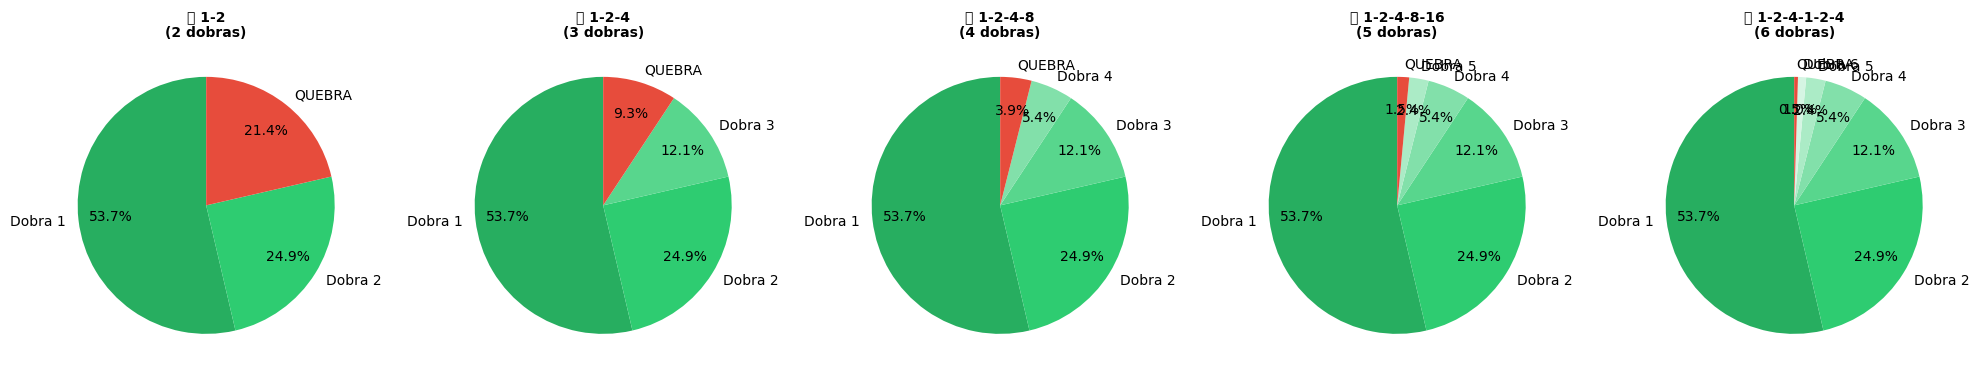


📁 Gráfico salvo: 02_distribuicao_resultados_dobras.png


In [11]:
# --- CÉLULA 11: GRÁFICO DE PIZZA - DISTRIBUIÇÃO DE RESULTADOS ---

fig, axes = plt.subplots(1, len(resultados), figsize=(20, 4))

cores_pizza = ['#27ae60', '#2ecc71', '#58d68d', '#82e0aa', '#abebc6', '#d5f5e3', '#e74c3c']

for idx, (nome, res) in enumerate(resultados.items()):
    ax = axes[idx]
    
    # Dados
    valores = list(res['wins'].values()) + [res['quebras']]
    labels = [f"Dobra {d}" for d in res['wins'].keys()] + ['QUEBRA']
    
    # Filtrar zeros
    dados_filtrados = [(v, l, c) for v, l, c in zip(valores, labels, cores_pizza[:len(valores)]) if v > 0]
    if dados_filtrados:
        valores_f, labels_f, cores_f = zip(*dados_filtrados)
        
        # Ajustar cores - quebra sempre vermelha
        cores_final = list(cores_f)
        if 'QUEBRA' in labels_f:
            cores_final[-1] = '#e74c3c'
        
        wedges, texts, autotexts = ax.pie(valores_f, labels=labels_f, colors=cores_final,
                                           autopct='%1.1f%%', startangle=90, pctdistance=0.75)
    
    ax.set_title(f"{res['config']['emoji']} {nome.split('(')[0].strip()}\n({res['num_dobras']} dobras)", 
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('02_distribuicao_resultados_dobras.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Gráfico salvo: 02_distribuicao_resultados_dobras.png")

In [12]:
# --- CÉLULA 12: CONCLUSÃO E RECOMENDAÇÕES ---

print("\n" + "="*80)
print("🏆 CONCLUSÃO E RECOMENDAÇÕES")
print("="*80)

# Ordenar por lucro
ranking_lucro = sorted(resultados.items(), key=lambda x: x[1]['lucro'], reverse=True)
# Ordenar por segurança (menos quebras)
ranking_seguranca = sorted(resultados.items(), key=lambda x: x[1]['quebras'])
# Ordenar por Sharpe
ranking_sharpe = sorted(resultados.items(), key=lambda x: x[1]['sharpe'], reverse=True)

print(f"""
📊 RANKINGS:

🏆 POR LUCRO TOTAL:
""")
for i, (nome, res) in enumerate(ranking_lucro, 1):
    emoji = "🥇" if i == 1 else ("🥈" if i == 2 else ("🥉" if i == 3 else f"{i}."))
    print(f"   {emoji} {nome}: R$ {res['lucro']:,.2f}")

print(f"""
🛡️ POR SEGURANÇA (menos quebras):
""")
for i, (nome, res) in enumerate(ranking_seguranca, 1):
    emoji = "🥇" if i == 1 else ("🥈" if i == 2 else ("🥉" if i == 3 else f"{i}."))
    print(f"   {emoji} {nome}: {res['quebras']} quebras ({res['taxa_win']:.2f}% win)")

print(f"""
📈 POR SHARPE RATIO (risco/retorno):
""")
for i, (nome, res) in enumerate(ranking_sharpe, 1):
    emoji = "🥇" if i == 1 else ("🥈" if i == 2 else ("🥉" if i == 3 else f"{i}."))
    print(f"   {emoji} {nome}: Sharpe = {res['sharpe']:.4f}")

# Análise específica do 1-2
res_1_2 = resultados['1-2 (2 dobras)']
res_1_2_4_1_2_4 = resultados['1-2-4-1-2-4 (6 dobras)']

print(f"""
{'─'*75}

🔍 ANÁLISE ESPECÍFICA: 1-2 vs 1-2-4-1-2-4

┌────────────────────────────────────────────────────────────────────────────┐
│ MÉTRICA                    │ 1-2 (2 dobras)     │ 1-2-4-1-2-4 (6 dobras)  │
├────────────────────────────────────────────────────────────────────────────┤
│ Quebra se                  │ {res_1_2['quebra_se']:>2}+ baixas         │ {res_1_2_4_1_2_4['quebra_se']:>2}+ baixas              │
│ Entradas                   │ {res_1_2['entradas']:>5,}              │ {res_1_2_4_1_2_4['entradas']:>5,}                 │
│ Quebras                    │ {res_1_2['quebras']:>5}              │ {res_1_2_4_1_2_4['quebras']:>5}                 │
│ Taxa de Vitória            │ {res_1_2['taxa_win']:>6.2f}%            │ {res_1_2_4_1_2_4['taxa_win']:>6.2f}%               │
│ Lucro Total                │ R$ {res_1_2['lucro']:>12,.2f}    │ R$ {res_1_2_4_1_2_4['lucro']:>12,.2f}       │
│ Lucro por Entrada          │ R$ {res_1_2['lucro_por_entrada']:>12,.2f}    │ R$ {res_1_2_4_1_2_4['lucro_por_entrada']:>12,.2f}       │
│ Max Drawdown               │ R$ {res_1_2['max_drawdown']:>12,.2f}    │ R$ {res_1_2_4_1_2_4['max_drawdown']:>12,.2f}       │
└────────────────────────────────────────────────────────────────────────────┘
""")

# Determinar recomendação
if res_1_2['lucro'] > 0:
    print(f"""
💡 CONCLUSÃO SOBRE 1-2:

   {'✅ LUCRATIVO!' if res_1_2['lucro'] > 0 else '❌ NÃO LUCRATIVO'}
   
   • Lucro de R$ {res_1_2['lucro']:,.2f} com {res_1_2['quebras']} quebras
   • Taxa de vitória: {res_1_2['taxa_win']:.2f}%
   • Risco: MUITO ALTO ({res_1_2['quebras']} quebras vs {res_1_2_4_1_2_4['quebras']} do 1-2-4-1-2-4)
   
   ⚠️ PORÉM: O lucro é {res_1_2['lucro']/res_1_2_4_1_2_4['lucro']*100:.0f}% do lucro do 1-2-4-1-2-4
   
   📊 VEREDICTO: {'Vale como opção conservadora' if res_1_2['lucro'] > res_1_2_4_1_2_4['lucro'] * 0.5 else 'NÃO recomendado - lucro muito baixo'}
""")
else:
    print(f"""
💡 CONCLUSÃO SOBRE 1-2:

   ❌ NÃO LUCRATIVO!
   
   • Prejuízo de R$ {abs(res_1_2['lucro']):,.2f}
   • As {res_1_2['quebras']} quebras consomem todo o lucro das vitórias
   • A estratégia não é sustentável
   
   📊 VEREDICTO: NÃO usar 1-2 com gatilho 6
""")


🏆 CONCLUSÃO E RECOMENDAÇÕES

📊 RANKINGS:

🏆 POR LUCRO TOTAL:

   🥇 1-2 (2 dobras): R$ 26,135.27
   🥈 1-2-4 (3 dobras): R$ 20,610.94
   🥉 1-2-4-8 (4 dobras): R$ 14,057.59
   4. 1-2-4-1-2-4 (6 dobras): R$ 12,676.12
   5. 1-2-4-8-16 (5 dobras): R$ 9,739.63

🛡️ POR SEGURANÇA (menos quebras):

   🥇 1-2-4-1-2-4 (6 dobras): 6 quebras (99.53% win)
   🥈 1-2-4-8-16 (5 dobras): 19 quebras (98.51% win)
   🥉 1-2-4-8 (4 dobras): 50 quebras (96.07% win)
   4. 1-2-4 (3 dobras): 118 quebras (90.72% win)
   5. 1-2 (2 dobras): 272 quebras (78.60% win)

📈 POR SHARPE RATIO (risco/retorno):

   🥇 1-2-4-1-2-4 (6 dobras): Sharpe = 0.1261
   🥈 1-2-4-8-16 (5 dobras): Sharpe = 0.1225
   🥉 1-2-4-8 (4 dobras): Sharpe = 0.1069
   4. 1-2-4 (3 dobras): Sharpe = 0.0982
   5. 1-2 (2 dobras): Sharpe = 0.0757

───────────────────────────────────────────────────────────────────────────

🔍 ANÁLISE ESPECÍFICA: 1-2 vs 1-2-4-1-2-4

┌────────────────────────────────────────────────────────────────────────────┐
│ MÉTRICA      

In [13]:
# --- CÉLULA 13: RECOMENDAÇÃO FINAL ---

print("\n" + "="*80)
print("📋 RECOMENDAÇÃO FINAL")
print("="*80)

# Encontrar melhor estratégia
melhor_nome, melhor_res = ranking_lucro[0]
mais_segura_nome, mais_segura_res = ranking_seguranca[0]

print(f"""
🎯 BASEADO NA ANÁLISE DE {len(multiplicadores):,} RODADAS:

┌─────────────────────────────────────────────────────────────────────────────┐
│                                                                             │
│  🏆 MELHOR LUCRO: {melhor_nome:<50} │
│     • Lucro: R$ {melhor_res['lucro']:>12,.2f}                                        │
│     • Quebras: {melhor_res['quebras']}                                                       │
│     • Taxa de vitória: {melhor_res['taxa_win']:.2f}%                                       │
│                                                                             │
│  🛡️ MAIS SEGURA: {mais_segura_nome:<50} │
│     • Lucro: R$ {mais_segura_res['lucro']:>12,.2f}                                        │
│     • Quebras: {mais_segura_res['quebras']}                                                       │
│     • Taxa de vitória: {mais_segura_res['taxa_win']:.2f}%                                       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘

💡 RECOMENDAÇÕES POR PERFIL:

   🔴 AGRESSIVO (máximo lucro, aceita risco):
      → {ranking_lucro[0][0]}
   
   🟡 MODERADO (equilíbrio lucro/risco):
      → {ranking_sharpe[0][0]}
   
   🟢 CONSERVADOR (mínimo risco):
      → {ranking_seguranca[0][0]}

📊 NOTA SOBRE 1-2:
   • É a estratégia mais arriscada (quebra com 8+ baixas)
   • Lucro: R$ {resultados['1-2 (2 dobras)']['lucro']:,.2f}
   • {'✅ Viável' if resultados['1-2 (2 dobras)']['lucro'] > 0 else '❌ Não viável'} como opção
""")


📋 RECOMENDAÇÃO FINAL

🎯 BASEADO NA ANÁLISE DE 105,281 RODADAS:

┌─────────────────────────────────────────────────────────────────────────────┐
│                                                                             │
│  🏆 MELHOR LUCRO: 1-2 (2 dobras)                                     │
│     • Lucro: R$    26,135.27                                        │
│     • Quebras: 272                                                       │
│     • Taxa de vitória: 78.60%                                       │
│                                                                             │
│  🛡️ MAIS SEGURA: 1-2-4-1-2-4 (6 dobras)                             │
│     • Lucro: R$    12,676.12                                        │
│     • Quebras: 6                                                       │
│     • Taxa de vitória: 99.53%                                       │
│                                                                             │
└──────────────────────────────

In [14]:
# --- CÉLULA 14: SALVAR RESULTADOS ---

# Criar DataFrame com resultados
df_resultados = pd.DataFrame([{
    'Estrategia': nome,
    'Dobras': res['num_dobras'],
    'Quebra_Se': res['quebra_se'],
    'Config': str(res['dobras_config']),
    'Entradas': res['entradas'],
    'Vitorias': sum(res['wins'].values()),
    'Quebras': res['quebras'],
    'Taxa_Vitoria': res['taxa_win'],
    'Lucro_Total': res['lucro'],
    'Lucro_Por_Entrada': res['lucro_por_entrada'],
    'Max_Drawdown': res['max_drawdown'],
    'Volatilidade': res['volatilidade'],
    'Sharpe_Ratio': res['sharpe']
} for nome, res in resultados.items()])

print("\n📊 Tabela de Resultados:")
display(df_resultados)

# Salvar
df_resultados.to_csv('resultados_comparacao_dobras.csv', index=False)
print("\n📁 Resultados salvos: resultados_comparacao_dobras.csv")


📊 Tabela de Resultados:


,Estrategia,Dobras,Quebra_Se,Config,Entradas,Vitorias,Quebras,Taxa_Vitoria,Lucro_Total,Lucro_Por_Entrada,Max_Drawdown,Volatilidade,Sharpe_Ratio
0,1-2 (2 dobras),2,8,"[1, 2]",1271,999,272,78.599528,26135.266667,20.562759,-5116.083333,271.738536,0.075671
1,1-2-4 (3 dobras),3,9,"[1, 2, 4]",1271,1153,118,90.715972,20610.942857,16.216320,-2546.550000,165.212875,0.098154
2,1-2-4-8 (4 dobras),4,10,"[1, 2, 4, 8]",1271,1221,50,96.066090,14057.586667,11.060257,-2151.906667,103.465727,0.106898
3,1-2-4-8-16 (5 dobras),5,11,"[1, 2, 4, 8, 16]",1271,1252,19,98.505114,9739.632258,7.662968,-1165.140323,62.569754,0.122471
4,1-2-4-1-2-4 (6 dobras),6,12,"[1, 2, 4, 1, 2, 4]",1271,1265,6,99.527931,12676.121429,9.973345,-1208.421429,79.103669,0.126079



📁 Resultados salvos: resultados_comparacao_dobras.csv
